# 10 — Final Demand-Forecasting Models (Consolidated)

This notebook is the single, organized view of the project's **final selected model per series** and the resulting **24-month demand forecast** (2026-01 to 2027-12). It is a *presentation / consolidation* notebook: it **reads the productionized Phase 2 outputs as the source of truth** and presents them — it does **not** re-fit models or re-run model selection, so it can never drift from what the production script (`scripts/05_modeling_with_cnmc.py`) actually produced.

### The per-region model is the best of pooled vs non-pooled — chosen honestly
Each of the 5 series uses whichever model won the **recursive multi-step walk-forward gate** on the **2023-2024 training data only**, subject to a **no-regression acceptance gate** on the 2025 holdout. Pooling (jointly fitting the regional panel, region as a feature — **never summing regions**, Nacional never pooled) is adopted **only where it genuinely helped**:

| Series | Final model | Pooled? | 2025 MAPE |
|---|---|---|---|
| Nacional | SARIMA | no | 29.0% |
| Madrid | Logistic curve | no | 73.6% |
| **Cataluña** | **Pooled Random Forest** | **yes** | **46.8%** |
| Andalucía | Logistic curve | no | 48.4% |
| Valencia | Gompertz curve | no | 34.2% |

> **No test-set cherry-picking.** Models are selected on training-period validation, never by their 2025 score. (E.g. Madrid's *pooled* model has a better 2025 number, but the training gate did not select it, so it is **not** used — using it would be selecting on the test set.) See `PHASE2_MODELING_REPORT.md`.

## 0. Setup — load the productionized Phase 2 outputs

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
REPO_ROOT    = NOTEBOOK_DIR.parent
OUT          = REPO_ROOT / 'data' / 'outputs'
FEAT         = REPO_ROOT / 'data' / 'features'

TARGETS = ['Nacional', 'Madrid', 'Cataluña', 'Andalucía', 'Valencia']
COLORS  = {'Nacional': '#FF6B35', 'Madrid': '#004E89', 'Cataluña': '#1A936F',
           'Andalucía': '#C84B31', 'Valencia': '#8E44AD'}

final    = pd.read_csv(OUT / 'metricas_final_seleccionado.csv')
accept   = pd.read_csv(OUT / 'phase2_model_acceptance.csv')
pool_exp = pd.read_csv(OUT / 'phase2_pooling_experiment_metrics.csv')
preds    = pd.read_csv(OUT / 'predicciones_test_2025.csv')
forecast = pd.read_csv(OUT / 'forecast_24m_sarima_rf_xgb.csv')
history  = pd.read_csv(FEAT / 'features_modelo_completo.csv')[['Fecha', 'Target', 'Consumo_Tm']]

SELECTED = dict(zip(final['Target'], final['Model']))
plt.rcParams['figure.dpi'] = 110
print('Final selected model per series:')
for t in TARGETS:
    print('  {:10s} -> {}'.format(t, SELECTED[t]))

Final selected model per series:
  Nacional   -> SARIMA
  Madrid     -> Logistic
  Cataluña   -> Pooled Random Forest
  Andalucía  -> Logistic
  Valencia   -> Gompertz


## 1. Final selected models & how each was chosen

The headline selection, then the decision trail. Models are chosen by the recursive multi-step walk-forward gate on 2023-2024 only; a no-regression acceptance gate then keeps the Phase 2 proposal only if it does not worsen the 2025 holdout versus the Phase 1 model. The pooled-candidate table shows *why* pooling is adopted only for Cataluña: Pooled Ridge explodes (no saturation ceiling), while Pooled Random Forest / XGBoost plateau safely but only win Cataluña's training gate.

In [2]:
# 1a. Final selected models + 2025 holdout metrics
tbl = final.copy()
tbl['Pooled'] = np.where(tbl['Model'].str.startswith('Pooled'), 'yes', 'no')
tbl = tbl[['Target', 'Model', 'Pooled', 'MAE', 'RMSE', 'MAPE', 'R2']]
print('FINAL SELECTED MODELS (2025 holdout):')
print(tbl.to_string(index=False))
avg = final['MAPE'].mean()
print()
print('Average selected 2025 MAPE: {:.1f}%  (was 94.6% before the Phase 2 gate + pooling)'.format(avg))

# 1b. Selection decision per series (Phase 1 vs Phase 2 proposal vs final)
print()
print('SELECTION DECISION (phase2_model_acceptance.csv):')
acc = accept[['Target', 'Phase1_Model', 'Phase1_MAPE', 'Phase2_Proposed_Model',
              'Phase2_Proposed_MAPE', 'Selected_Model', 'Decision']]
print(acc.to_string(index=False))

# 1c. Pooled candidates on the 2025 holdout -> why pooling helps only Cataluña
print()
print('POOLED CANDIDATES, 2025 holdout MAPE (%):')
pe = pool_exp.pivot_table(index='Target', columns='Model', values='MAPE')
cols = [c for c in ['Pooled Ridge', 'Pooled Random Forest', 'Pooled XGBoost'] if c in pe.columns]
print(pe[cols].round(1).to_string())
print()
print('Pooled Ridge MAPE is in the tens-of-thousands of % (unbounded blow-up) -> ruled out.')

FINAL SELECTED MODELS (2025 holdout):
   Target                Model Pooled    MAE   RMSE  MAPE     R2
 Nacional               SARIMA     no 4278.0 4921.8  29.0 -0.009
   Madrid             Logistic     no 1924.0 2057.2  73.6 -8.273
 Cataluña Pooled Random Forest    yes 1424.3 1556.5  46.8 -5.158
Andalucía             Logistic     no  833.8 1006.7  48.4 -1.555
 Valencia             Gompertz     no  360.3  446.6  34.2 -1.246

Average selected 2025 MAPE: 46.4%  (was 94.6% before the Phase 2 gate + pooling)

SELECTION DECISION (phase2_model_acceptance.csv):
   Target Phase1_Model  Phase1_MAPE Phase2_Proposed_Model  Phase2_Proposed_MAPE       Selected_Model                  Decision
 Nacional       SARIMA         29.0              Logistic                  36.7               SARIMA kept_phase1_no_regression
   Madrid     Gompertz        197.1              Logistic                  73.6             Logistic    accepted_no_regression
 Cataluña     Gompertz        164.2  Pooled Random Forest 

## 2. Results — 2025 holdout fit & the 24-month forecast

First, each series' selected model against the realized 2025 values. Then the deliverable: 2023-2025 history plus the 24-month forward forecast (the dotted grey line marks the train/forecast boundary at 2025-12).

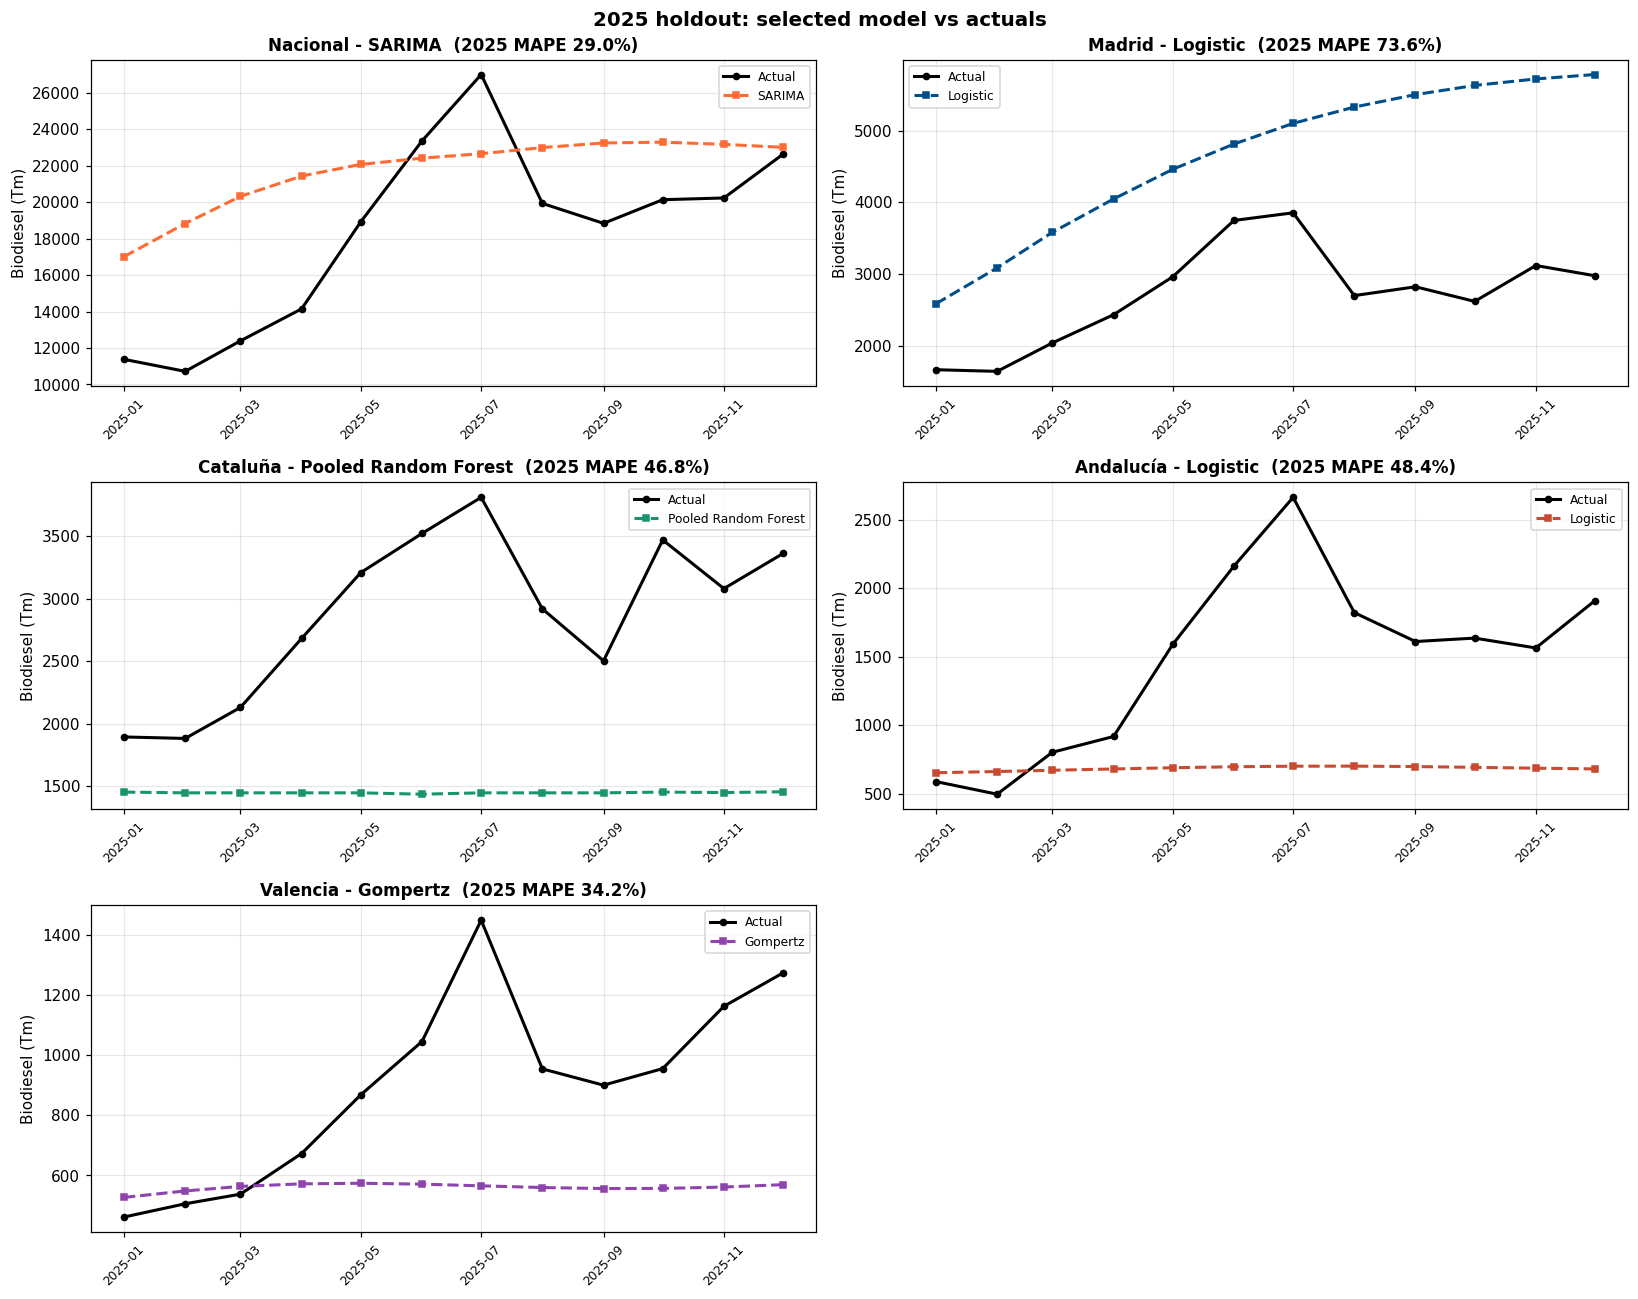

In [3]:
# 2025 holdout: selected model vs actuals
fig, axes = plt.subplots(3, 2, figsize=(15, 12)); axes = axes.ravel()
for i, t in enumerate(TARGETS):
    ax = axes[i]; m = SELECTED[t]
    d = preds[(preds['Target'] == t) & (preds['Model'] == m)].sort_values('Fecha').copy()
    d['date'] = pd.to_datetime(d['Fecha'])
    ax.plot(d['date'], d['Actual'], 'o-', color='black', lw=2, ms=4, label='Actual')
    ax.plot(d['date'], d['Pred'], 's--', color=COLORS[t], lw=2, ms=4, label=m)
    mape = float(final[final['Target'] == t]['MAPE'].iloc[0])
    ax.set_title('{} - {}  (2025 MAPE {:.1f}%)'.format(t, m, mape), fontsize=11, weight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_ylabel('Biodiesel (Tm)')
axes[-1].axis('off')
fig.suptitle('2025 holdout: selected model vs actuals', fontsize=13, weight='bold')
fig.tight_layout(); plt.show()

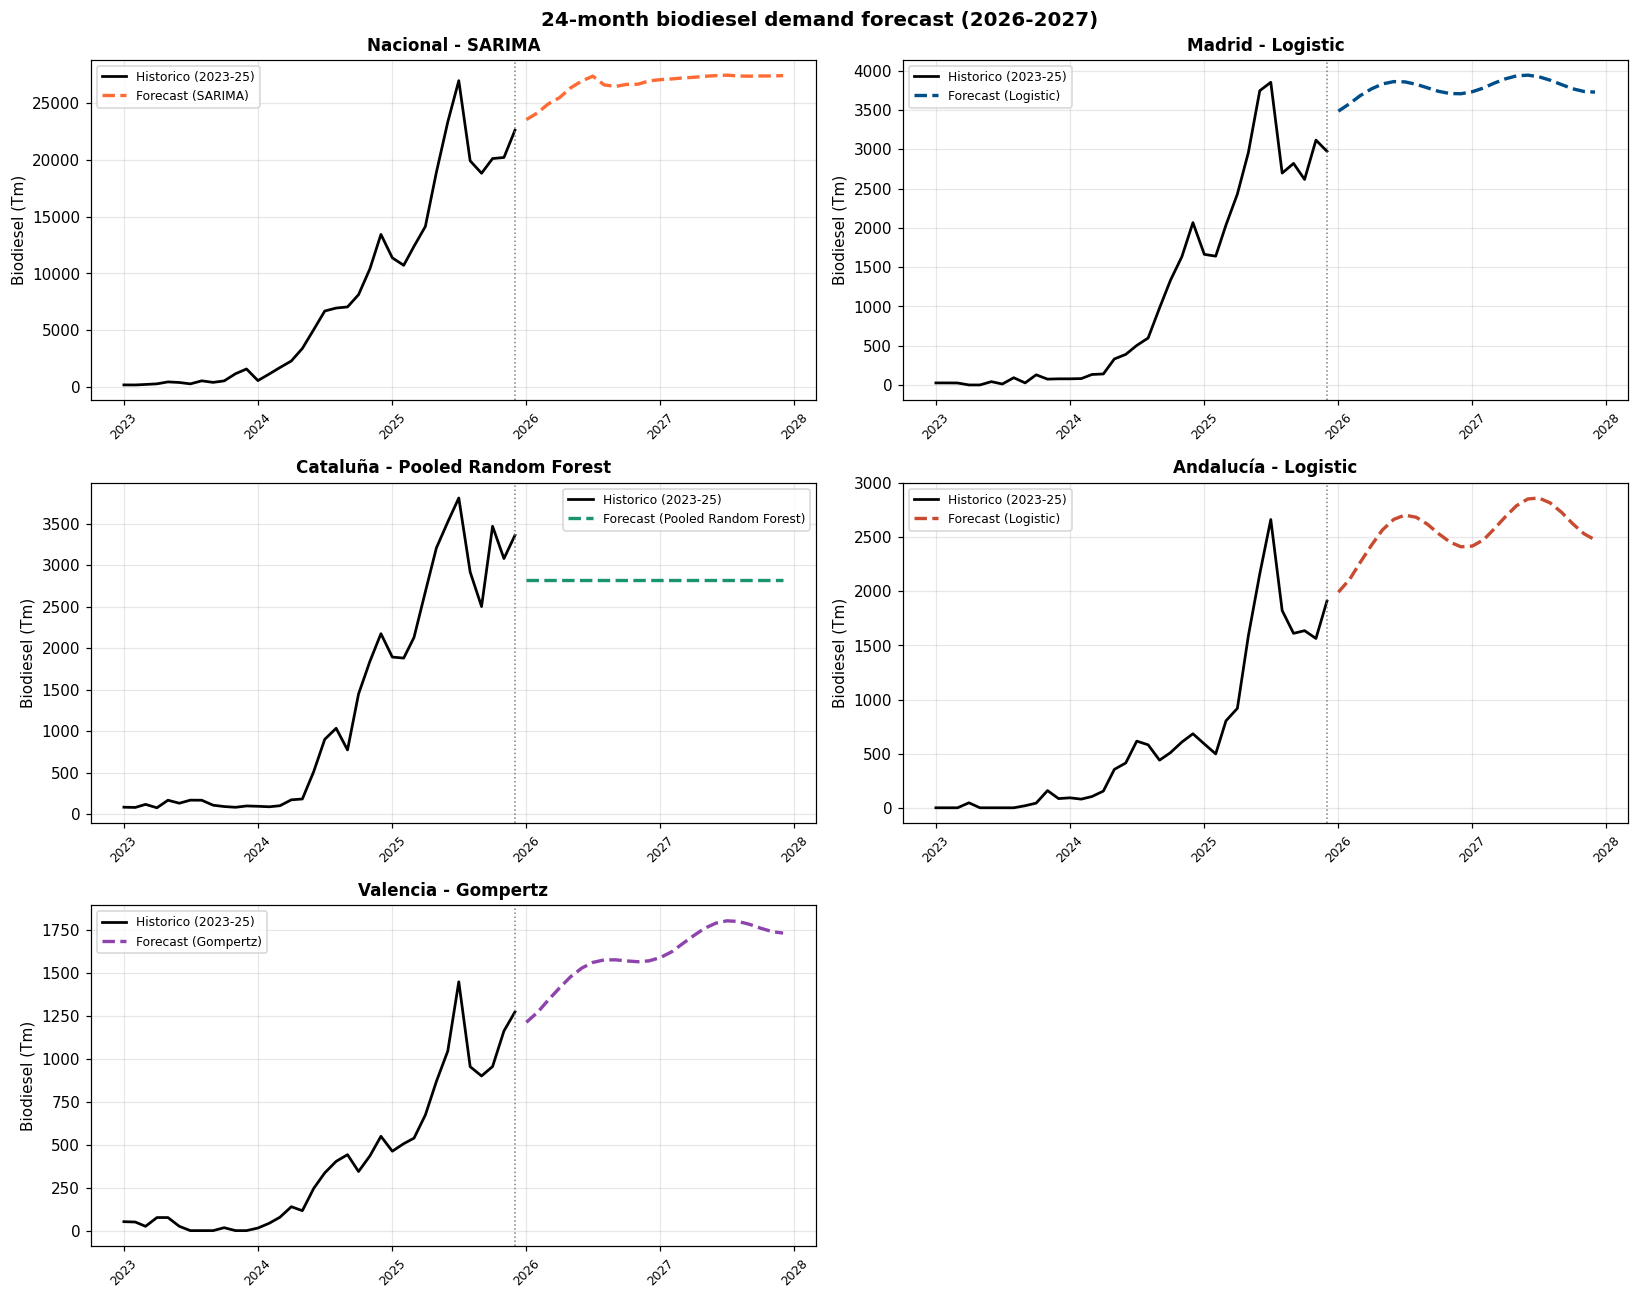

In [4]:
# 24-month forecast (2026-2027): history + selected-model forecast
fig, axes = plt.subplots(3, 2, figsize=(15, 12)); axes = axes.ravel()
cut = pd.to_datetime('2025-12')
for i, t in enumerate(TARGETS):
    ax = axes[i]; m = SELECTED[t]
    h = history[history['Target'] == t].sort_values('Fecha').copy()
    fc = forecast[(forecast['Target'] == t) & (forecast['Model'] == m)].sort_values('Fecha').copy()
    h['date'] = pd.to_datetime(h['Fecha']); fc['date'] = pd.to_datetime(fc['Fecha'])
    ax.plot(h['date'], h['Consumo_Tm'], '-', color='black', lw=1.8, label='Historico (2023-25)')
    ax.plot(fc['date'], fc['Forecast'], '--', color=COLORS[t], lw=2.2, label='Forecast ({})'.format(m))
    ax.axvline(cut, color='grey', ls=':', lw=1)
    ax.set_title('{} - {}'.format(t, m), fontsize=11, weight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_ylabel('Biodiesel (Tm)')
axes[-1].axis('off')
fig.suptitle('24-month biodiesel demand forecast (2026-2027)', fontsize=13, weight='bold')
fig.tight_layout(); plt.show()

In [5]:
# Annual forecast totals (sum of each series' SELECTED model over each year)
f = forecast.merge(pd.DataFrame(SELECTED.items(), columns=['Target', 'Model']), on=['Target', 'Model'])
f['Year'] = f['Fecha'].str[:4]
annual = f.pivot_table(index='Target', columns='Year', values='Forecast', aggfunc='sum').round(0)
annual = annual.reindex(TARGETS)
print('Forecast biodiesel demand (Tm) - annual totals of the per-series selected model:')
print(annual.to_string())

Forecast biodiesel demand (Tm) - annual totals of the per-series selected model:
Year           2026      2027
Target                       
Nacional   312379.0  328205.0
Madrid      44848.0   46008.0
Cataluña    33865.0   33865.0
Andalucía   29441.0   31856.0
Valencia    17656.0   20760.0


## Summary & caveats

- **What this is:** the consolidated final model set — per series, the best of pooled vs non-pooled, chosen by a training-only recursive walk-forward gate with a no-regression acceptance check. Average 2025 MAPE **94.6% to 46.4%**. Pooling adopted only for **Cataluña** (164% to 47%).
- **Honest limits (carry these into any Repsol-facing deck):**
  - Only 36 months of data (24 training); R2 is negative for every series except near-zero Nacional. Present these as **directional planning scenarios**, not precise demand commitments.
  - **Cataluña's Pooled Random Forest is a conservative *plateau* forecast** (tree models interpolate learned levels; they do not extrapolate a new growth trend). It is kept because it beats the alternatives on validation and avoids explosive behaviour — but it should be described as a plateau, not a structural growth curve.
- **Provenance:** all numbers are read from `data/outputs/` (Phase 2). Source of truth = `scripts/05_modeling_with_cnmc.py`; full rationale = `PHASE2_MODELING_REPORT.md`. This notebook re-derives nothing.